# 8.3.3 缩放选参与独立预测

## 学习目标与先修知识

只从训练集（training set）估计预处理量，只用验证集（validation set）选参并保留最终评估。

先修：6.6辨识中的信息边界，8.3.1—8.3.2的两种惩罚。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两个机制字典列几乎共线。我们想比较无惩罚、岭和稀疏拟合，怎样保证比较看到的是独立预测，而不是事后选出来的最好成绩？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
t=np.arange(90);u=np.sin(.19*t)+.4*np.cos(.07*t);v=u+.09*np.sin(.71*t)
X=np.column_stack([u,v]);y=.3+1.4*u+.13*np.cos(1.7*t)
train,valid,test=slice(0,45),slice(45,65),slice(65,90)
print('固定时间分段长度',len(X[train]),len(X[valid]),len(X[test]))
print('训练相关系数',np.corrcoef(X[train].T)[0,1])

固定时间分段长度 45 20 25
训练相关系数 0.9967578782778829


## 模型假设

人工观测（observation）只是一个可重复的无量纲（dimensionless）拟合任务；清除机制的生物含义需要另证。分段、候选λ和更新预算在看最终评估结果前固定。三种方法用同一观测、字典、标准化、截距与MSE。数据有时间次序，本节按连续段划分，不宣称消除了所有分布（distribution）变化。

## 数学解释与推导


训练集每列均值 $m_j$ 和总体标准差（standard deviation） $s_j$ 给出 $z_j=(x_j-m_j)/s_j$。
均值与标准差都只由训练行计算；若训练列恒定，约定尺度置1，并报告该列未获激励。
后续列偏离训练常数时，变换仍为 $x_j-m_j$，不能悄悄清零。

训练响应中心化为 $\tilde y=y-\bar y_{\rm train}$。
标准化列在训练集上均值为零，对平方损失且不惩罚截距的模型（model），截距最优值就是训练响应均值。
预测为 $\hat y=\bar y_{\rm train}+\sum_jz_j\beta_j$。
如需返回原单位系数，$a_j=\beta_j/s_j$，$a_0=\bar y_{\rm train}-\sum_jm_ja_j$。
L1惩罚 $\lambda\sum_j|\beta_j|=\lambda\sum_js_j|a_j|$，因此缩放并非对惩罚无影响。

对每个候选λ，仅在训练集拟合；在验证集上比较
$\mathrm{MSE}_{\rm val}=n_{\rm val}^{-1}\sum_i(y_i-\hat y_i)^2$，平分时取较小λ。
固定选择后，最终段只评估一次。若查看最终段后更改字典、尺度、λ或迭代次数，该段已参与选择，之后需要新的独立评估。
稀疏优化额外检查近端映射残差（residual），避免把尚未收敛的系数差异当作正则化（regularization）差异。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def solve_linear(matrix, right):
    """Partial-pivot elimination for the tiny classroom systems."""
    rows = [list(map(float, row))+[float(value)] for row, value in zip(matrix, right)]
    size = len(rows)
    for column in range(size):
        pivot = max(range(column, size), key=lambda i: abs(rows[i][column]))
        if abs(rows[pivot][column]) < 1e-12:
            return None
        rows[column], rows[pivot] = rows[pivot], rows[column]
        scale = rows[column][column]
        rows[column] = [value/scale for value in rows[column]]
        for i in range(size):
            if i != column:
                factor = rows[i][column]
                rows[i] = [a-factor*b for a, b in zip(rows[i], rows[column])]
    return [row[-1] for row in rows]


def ridge_fit(design, observed, penalty):
    count, width = len(design), len(design[0])
    matrix = [[sum(row[i]*row[j] for row in design)/count+(penalty if i==j else 0)
               for j in range(width)] for i in range(width)]
    right = [sum(row[i]*y for row, y in zip(design, observed))/count for i in range(width)]
    coefficients = solve_linear(matrix, right)
    return coefficients, 'unique' if coefficients is not None else 'nonunique'


def soft_threshold(values, threshold):
    return [math.copysign(max(abs(value)-threshold, 0.), value) if abs(value)>threshold else 0.
            for value in values]


def proximal_step(design, observed, coefficients, step, penalty):
    count = len(design)
    residuals = [sum(x*b for x, b in zip(row, coefficients))-y
                 for row, y in zip(design, observed)]
    gradient = [sum(row[j]*r for row, r in zip(design, residuals))/count
                for j in range(len(coefficients))]
    updated = soft_threshold([b-step*g for b, g in zip(coefficients, gradient)], step*penalty)
    errors = [sum(x*b for x, b in zip(row, updated))-y for row, y in zip(design, observed)]
    value = sum(r*r for r in errors)/(2*count)+penalty*sum(abs(b) for b in updated)
    return updated, value


def proximal_trace(design, observed, initial, step, penalty, steps):
    history = [list(initial)]
    objectives = [proximal_step(design, observed, initial, 0., penalty)[1]]
    for _ in range(steps):
        point, value = proximal_step(design, observed, history[-1], step, penalty)
        history.append(point); objectives.append(value)
    return history, objectives


def train_scaling(training, later):
    count, width = len(training), len(training[0])
    means = [sum(row[j] for row in training)/count for j in range(width)]
    scales = [math.sqrt(sum((row[j]-means[j])**2 for row in training)/count) for j in range(width)]
    scales = [s if s>0 else 1. for s in scales]
    transformed = [[(x-m)/s for x, m, s in zip(row, means, scales)] for row in later]
    return means, scales, transformed


def select_ridge(training, train_targets, validation, validation_targets, candidates):
    means, scales, train_x = train_scaling(training, training)
    _, _, validation_x = train_scaling(training, validation)
    intercept = sum(train_targets)/len(train_targets)
    centered = [y-intercept for y in train_targets]
    scores = []
    coefficients = []
    for penalty in candidates:
        fitted, status = ridge_fit(train_x, centered, penalty)
        if status != 'unique':
            raise ValueError('候选正则强度应严格大于零。')
        predicted = [intercept+sum(x*b for x, b in zip(row, fitted)) for row in validation_x]
        scores.append(sum((a-b)**2 for a, b in zip(predicted, validation_targets))/len(predicted))
        coefficients.append(fitted)
    chosen = min(range(len(scores)), key=lambda i: (scores[i], candidates[i]))
    return dict(penalty=candidates[chosen], coefficients=coefficients[chosen],
                means=means, scales=scales, intercept=intercept, validation_scores=scores)

## 对照实验

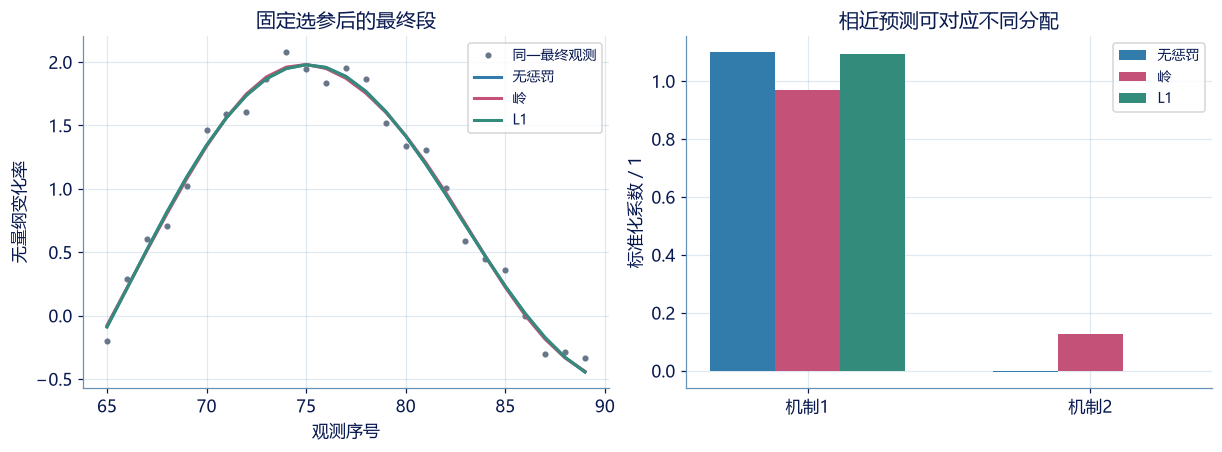

| 方法 | 系数1 | 系数2 | 验证MSE | 最终MSE |
| --- | --- | --- | --- | --- |
| 无惩罚 | 1.09927 | -0.00433 | 0.00822765 | 0.00861645 |
| 岭 | 0.96892 | 0.12547 | 0.00833904 | 0.00866657 |
| L1 | 1.09395 | 0 | 0.00823021 | 0.00860968 |

选择λ：岭 0.001 L1 0.001


In [4]:
choices=[.001,.01,.1,1.]
selection=select_ridge(X[train].tolist(),y[train].tolist(),X[valid].tolist(),y[valid].tolist(),choices)
means,scales,_=train_scaling(X[train].tolist(),[]);Z=(X-means)/scales;intercept=float(y[train].mean());yc=y[train]-intercept
ols=np.linalg.lstsq(Z[train],yc,rcond=None)[0]
ridge=np.array(selection['coefficients'])
L=np.linalg.eigvalsh(Z[train].T@Z[train]/len(yc))[-1];eta=1/L
sparse_candidates=[]
for lam in choices:
    path,_=proximal_trace(Z[train].tolist(),yc.tolist(),[0.,0.],eta,lam,4000)
    beta=np.array(path[-1]);score=float(np.mean((intercept+Z[valid]@beta-y[valid])**2))
    sparse_candidates.append((score,lam,beta))
_,sparse_lambda,sparse=min(sparse_candidates,key=lambda item:(item[0],item[1]))
fits={'无惩罚':ols,'岭':ridge,'L1':sparse};rows=[]
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(t[test],y[test],'.',color=GRAY,label='同一最终观测')
for (name,beta),color in zip(fits.items(),[BLUE,PINK,GREEN]):
    predicted=intercept+Z@beta
    rows.append([name,*np.round(beta,5),float(np.mean((predicted[valid]-y[valid])**2)),float(np.mean((predicted[test]-y[test])**2))])
    axes[0].plot(t[test],predicted[test],color=color,label=name)
axes[0].set(xlabel='观测序号',ylabel='无量纲变化率',title='固定选参后的最终段');axes[0].legend(fontsize=9)
positions=np.arange(2)
for j,((name,beta),color) in enumerate(zip(fits.items(),[BLUE,PINK,GREEN])):
    axes[1].bar(positions+(j-1)*.23,beta,width=.23,color=color,label=name)
axes[1].set(xticks=positions,xticklabels=['机制1','机制2'],ylabel='标准化系数 / 1',title='相近预测可对应不同分配');axes[1].legend(fontsize=9);plt.show()
display(Markdown(show_table(['方法','系数1','系数2','验证MSE','最终MSE'],rows)))
print('选择λ：岭',selection['penalty'],'L1',sparse_lambda)

### 独立核验与边界

In [5]:
np.testing.assert_allclose(means,X[train].mean(axis=0));np.testing.assert_allclose(scales,X[train].std(axis=0))
again=select_ridge(X[train].tolist(),y[train].tolist(),X[valid].tolist(),y[valid].tolist(),choices)
assert again==selection  # 选择函数根本不接收最终段
changed_test=X[test]*100  # 改动未见情景，不回传给选参过程
_,_,new= train_scaling([[1.,5.],[3.,5.]],[[5.,7.]])
np.testing.assert_allclose(new,[[3.,2.]])
next_sparse,_=proximal_step(Z[train].tolist(),yc.tolist(),sparse.tolist(),eta,sparse_lambda)
assert np.linalg.norm((sparse-next_sparse)/eta)<1e-6
original_coefficients=sparse/np.array(scales);original_intercept=intercept-np.array(means)@original_coefficients
np.testing.assert_allclose(intercept+Z@sparse,original_intercept+X@original_coefficients)
print('预处理、常量列、稀疏停止残差和原坐标预测一致性通过。')

预处理、常量列、稀疏停止残差和原坐标预测一致性通过。


## 结果解释

两列强相关时，相近的预测可以对应不同的系数分配。结合验证误差与最终误差，可以看出所选正则强度在两段数据上的表现；若据此改进模型，再用新的评估数据检验。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：固定训练尺度后变换新数据

只使用training计算每列均值与总体标准差（standard deviation），然后变换later。

**函数与代码模板**

```python
def solve(
    training: list[list[float]],
    later: list[list[float]],
) -> tuple[list[float], list[float], list[list[float]]]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `training` | `list[list[float]]` | 训练行，每行2个变量。 | 无量纲 |
| `later` | `list[list[float]]` | 待变换的验证或未来行，可为空。 | 无量纲 |

**返回值**

按以下顺序返回元组：(means, scales, transformed)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 训练列均值。 | 无量纲 |
| `scales` | `list[float]` | 训练总体标准差，零值改为1。 | 无量纲 |
| `transformed` | `list[list[float]]` | later按(x−mean)/scale变换后的行。 | 无量纲 |

**计算规则**

标准差分母为训练行数n，不是n−1；later不能参与均值或尺度估计。常量训练列的尺度置1，未来偏离仍保留，不直接清零。

**约束与边界**

- training至少1行、至多30行；later长度0—30；每行2个数，绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| training | 训练行，每行2个变量。 | [[1.0, 5.0], [3.0, 5.0]] | 无量纲 |
| later | 待变换的验证或未来行，可为空。 | [[5.0, 7.0]] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
training = [[1.0, 5.0], [3.0, 5.0]]
later = [[5.0, 7.0]]

result = solve(training, later)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 训练列均值。 | [2.0, 5.0] | 无量纲 |
| scales | 训练总体标准差，零值改为1。 | [1.0, 1.0] | 无量纲 |
| transformed | later按(x−mean)/scale变换后的行。 | [[3.0, 2.0]] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2.0, 5.0], [1.0, 1.0], [[3.0, 2.0]])
```

**样例解释**

训练均值[2,5]、尺度[1,1]，所以新行变为[3,2]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定训练尺度后变换新数据](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-training-scale)

### 第 2 题 · 多项选择题：哪一组数据选择λ

已经固定训练、验证和最终评估三段。以下哪些做法保持最终评估独立？

- **A.** 训练集（training set）估计均值和尺度，应用到后两段。
- **B.** 在验证集（validation set）上选择候选λ，然后只报告一次最终评估。
- **C.** 查看最终误差后重选λ，但仍称该误差为未见成绩。
- **D.** 最终评估变差时如实报告，并另找新数据评估后续修改。

[作答：哪一组数据选择λ](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-split-protocol)

### 第 3 题 · 单项选择题：训练中恒定的变量

训练时某列始终为5，后续值为7。按本节标准化契约置尺度为1后，哪项正确？

- **A.** 后续该坐标为2；这暴露训练中没见过的变化。
- **B.** 后续该坐标强制为0。
- **C.** 需要用后续值重新估计训练方差（variance）。
- **D.** 训练恒定足以证明该机制永远不变。

[作答：训练中恒定的变量](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-constant-column)

### 第 4 题 · 多项选择题：预测好不等于参数对

含相关机制字典的模型（model）预测误差很小。哪些解释仍需谨慎？

- **A.** 可直接确认每个系数的生理含义。
- **B.** 多个系数组合可能给出近似相同预测。
- **C.** 应另查激励与可辨识性（identifiability）。
- **D.** 留出情形超出训练范围时，预测可恶化。

[作答：预测好不等于参数对](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-prediction-and-truth)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第6章的正则拟合；[Parikh 与 Boyd：Proximal Algorithms，§4.2、§6.5.2](https://web.stanford.edu/~boyd/papers/prox_algs.html)，近端算法的计算与停止。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-03-正则化与稀疏优化/explore/) · [本篇目录](../README.md)